In [1]:
import numpy as np # numerical values
import pandas as pd # tables
import matplotlib.pyplot as plt # for plots

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("The environment is ready: pandas", pd.__version__)

The environment is ready: pandas 3.0.3


In [2]:
# SCHEMA MAP 
# Schema map - a set of rules that define how data fields and tables in one system correspond to elements from another system.

TARGET = "esi" # ESI - Emeergency Severity Index

# Vital signs that are measured during triage 
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

# Information regarding the patitent 
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion", 
                "maritalstatus", "employstatus", "insurance_status"]

# Administrative details 
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

# Outcomes of the visit. This information is known AFTER triage and therfore not included in the model
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame columns into families and return them in a dictionary"""
    def keep_present(wanted):         # wanted = list of column names to check
        present = []                  # hold any columns that exist 
        for col in wanted:            # go through each requested colum
            if col in df.columns:     # check if it is in the dataset
                present.append(col)   # present? keep
        return present
    
    chief_complaints = []                   # hold all chief-complaint column names
    for col in df.columns:                  # go through every column of the dataset
        if col.startswith("cc_"):           # checks if it is a chief-complaint flag   
            chief_complaints.append(col)    # if present, adds to list

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families 

In [3]:
# Reference ranges for an adult triage. 
# Celsius version for temperature is included. 

NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), 
    "triage_vital_temp_c":(30,43.3), "triage_glucose": (70,140,"mg/dL")}

PLAUSIBLE ={"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_vital_temp_c": (30,43.3), "triage_glucose": (20,800)}


In [4]:
import os
def clean_triage(raw):
    """ WEEK-5 Cleaning Pipeline: Takes the raw DataFrame and returns a cleaned copy """
    d = raw.copy()
    fam = classify_columns(d)

    # 1. remove rows with no triage label
    d = d[d[TARGET].notna()].copy()

    #2. Vital sign and columns a numeric
    numeric_cols = list(fam["vitals"])      # creates a copy of the vital sign list
    if "age" in d.columns:
        numeric_cols.append("age")
    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")
    
    #3. Flag impossible values as NaN
    for col in PLAUSIBLE:
        low, high = PLAUSIBLE[col]
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            d.loc[out_of_range, col] = np.nan

 # 4. Fill in the gaps.
    for col in fam["vitals"]:
        d[col] = d[col].fillna(d[col].median())

    # A blank oxygen-device flag or chief-complaint flag means 0.
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = d["triage_vital_o2_device"].fillna(0)
    for col in fam["chief_complaints"]:
        d[col] = d[col].fillna(0)
        
    # Text categories: a blank becomes the explicit category "Unknown".
    for col in fam["demographics"] + fam["admin"] + fam["leakage"]:
        if d[col].dtype == object:
            d[col] = d[col].fillna("Unknown")

    # 5. The target should be a whole number 1-5, not a decimal.
    d[TARGET] = d[TARGET].round().astype(int)
    return d

In [5]:
from pathlib import Path

# cleaned version or the raw dataset
CLEAN_PATH, RAW_PATH = Path("data/triage_cleaned_v1.csv"), Path("data/yaleemmlc_admissionprediction_triage.csv")

if CLEAN_PATH.exists():
    df = pd.read_csv(CLEAN_PATH); print("Loaded cleaned data from Tutorial 3")
elif RAW_PATH.exists():
    df = clean_triage(pd.read_csv(RAW_PATH, index_col=0)); print("Rebuilt from raw via clean_triage()")
else:
    raise FileNotFoundError("Need triage_cleaned_v1.csv or the raw CSV.")

raw = pd.read_csv(RAW_PATH, index_col=0) if RAW_PATH.exists() else None
fam = classify_columns(df); os.makedirs("figs", exist_ok=True); print(df.shape)

Rebuilt from raw via clean_triage()
(55121, 225)


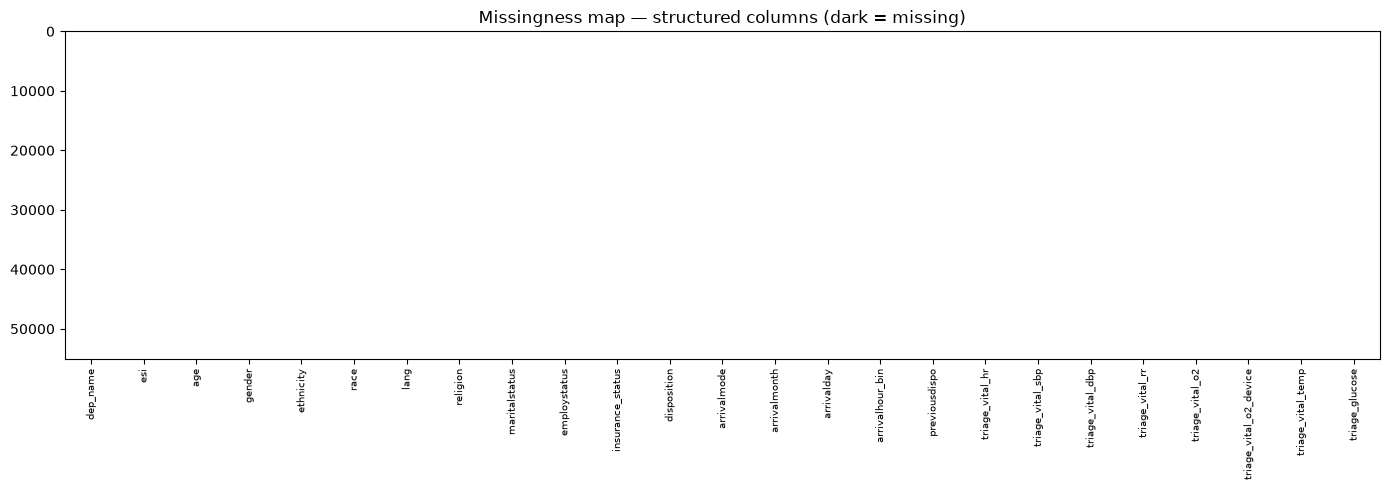

In [6]:
# Use the raw data if we have it (shows missingness before cleaning), otherwise use df
src = (raw if raw is not None else df)
structured = [c for c in src.columns if not c.startswith("cc_")]

# Build the True/False grid: True = missing, False = present
missing_grid = src[structured].isna().values

# Create the figure and axis to draw on
fig, ax = plt.subplots(figsize=(14, 5))

# Paint the grid: aspect="auto" stretches it to fit the figure nicely,
# cmap="gray_r" makes missing cells dark and present cells light
ax.imshow(missing_grid, aspect="auto", cmap="gray_r")

# Label each column along the x-axis, rotated so long names don't overlap
ax.set_xticks(range(len(structured)))
ax.set_xticklabels(structured, rotation=90, fontsize=7)

ax.set_title("Missingness map — structured columns (dark = missing)")

plt.tight_layout()
plt.savefig("figs/01_missingness.png", dpi=110)
plt.show()

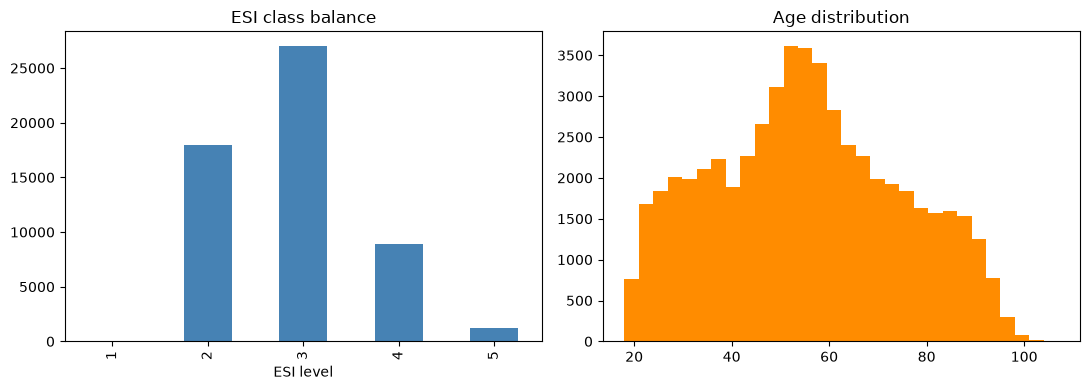

In [7]:
# Plotting ESI and age distribution

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Left panel: ESI class balance as a bar chart
esi_counts = df[TARGET].value_counts().sort_index()
esi_counts.plot.bar(ax=ax[0], color="steelblue")
ax[0].set_title("ESI class balance")
ax[0].set_xlabel("ESI level")

# Right panel: age distribution as a histogram
ax[1].hist(df["age"], bins=30, color="darkorange")
ax[1].set_title("Age distribution")

plt.tight_layout()
plt.savefig("figs/02_esi_age.png", dpi=110)
plt.show()

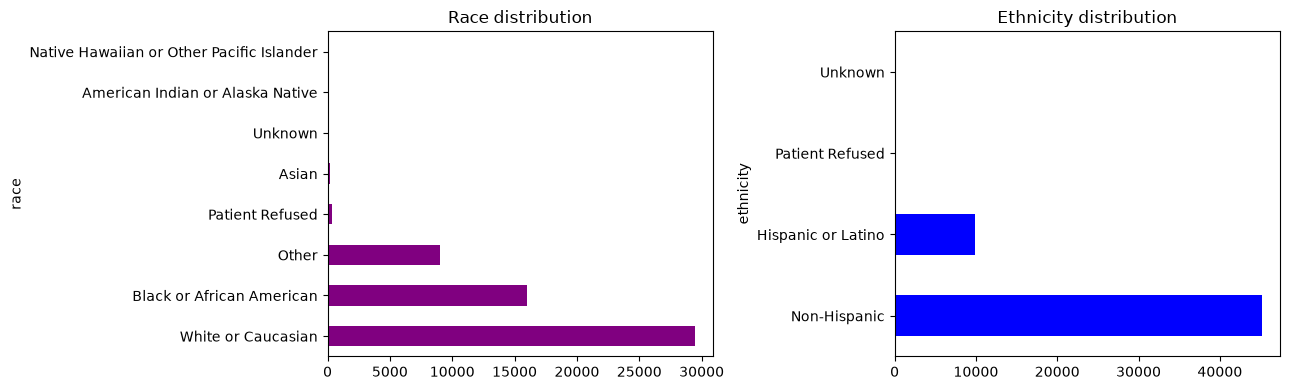

In [8]:
# Race and Ethnicity
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Left panel: race as a horizontal bar chart
race_counts = df["race"].value_counts()
race_counts.plot.barh(ax=ax[0], color="purple")
ax[0].set_title("Race distribution")

# Right panel: ethnicity as a horizontal bar chart
ethnicity_counts = df["ethnicity"].value_counts()
ethnicity_counts.plot.barh(ax=ax[1], color="blue")
ax[1].set_title("Ethnicity distribution")

plt.tight_layout()
plt.savefig("figs/03_demographics.png", dpi=110)
plt.show()

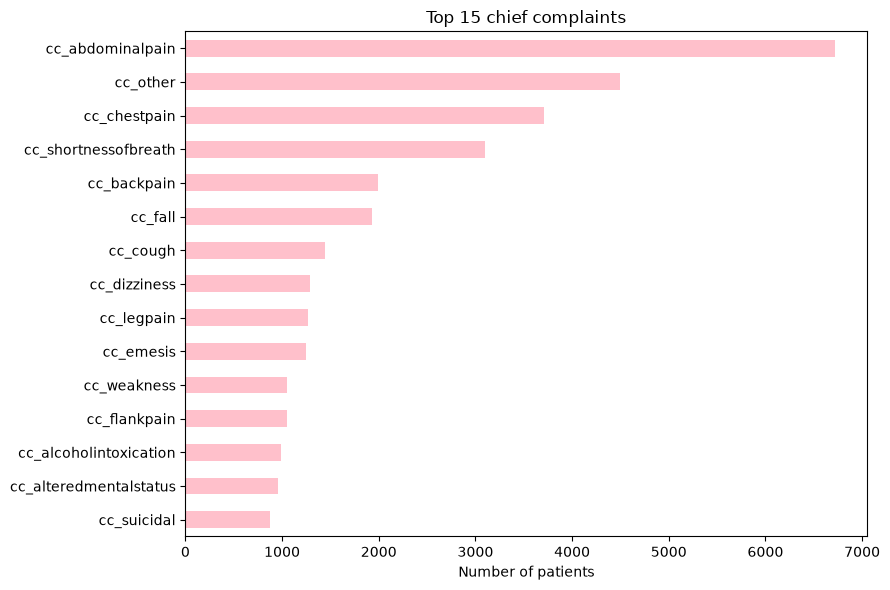

In [9]:
# Top Chief Complaints
# Count each complaint by summing its 0 or 1 flag column across all patients
complaint_counts = df[fam["chief_complaints"]].sum()

# Sort descending and keep only the top 15
top15 = complaint_counts.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))

# [::-1] reverses the order so the biggest bar lands at the TOP, not the bottom
top15[::-1].plot.barh(ax=ax, color="pink")

ax.set_title("Top 15 chief complaints")
ax.set_xlabel("Number of patients")

plt.tight_layout()
plt.savefig("figs/04_chief_complaints.png", dpi=110)
plt.show()

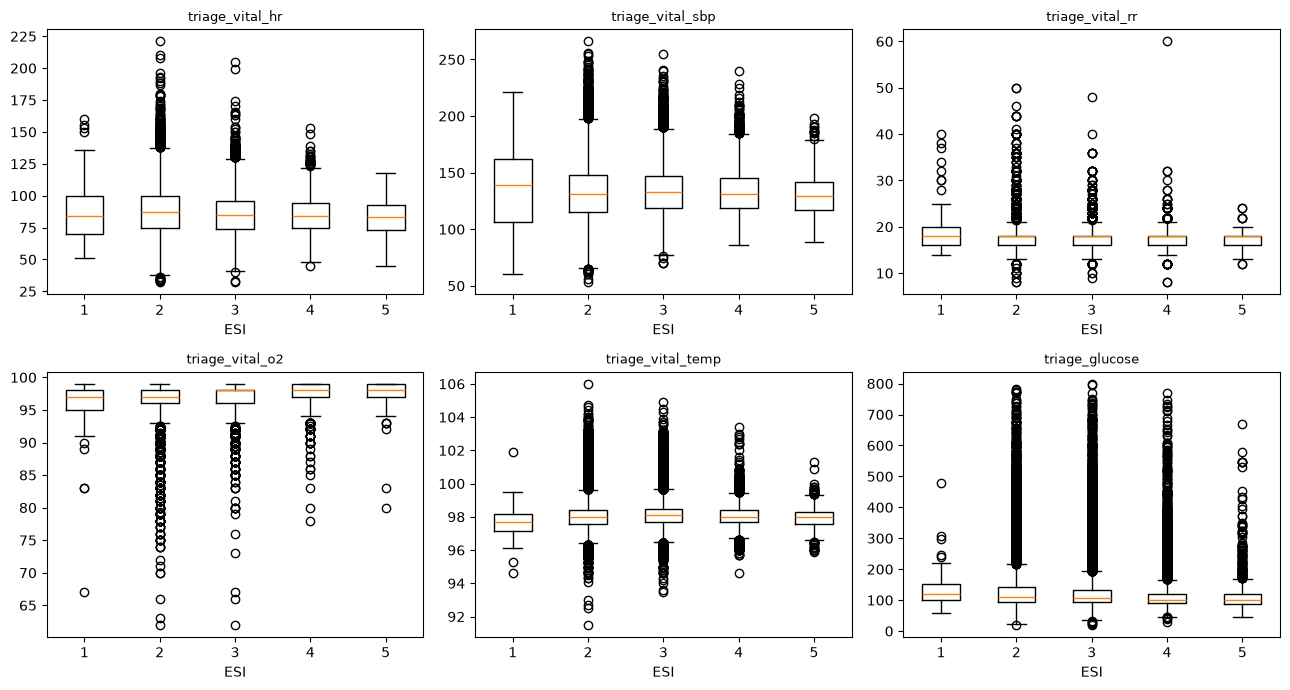

In [10]:
#  Vitals by ESI

vitals_to_plot = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_rr",
                   "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
esi_levels = sorted(df[TARGET].unique())

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for panel, col in zip(axes.ravel(), vitals_to_plot):
    # Build one group of values per ESI level for this vital
    groups = [df.loc[df[TARGET] == level, col] for level in esi_levels]
    
    panel.boxplot(groups, tick_labels=esi_levels)
    panel.set_title(col, fontsize=9)
    panel.set_xlabel("ESI")

plt.tight_layout()
plt.savefig("figs/05_vitals_by_esi.png", dpi=110)
plt.show()

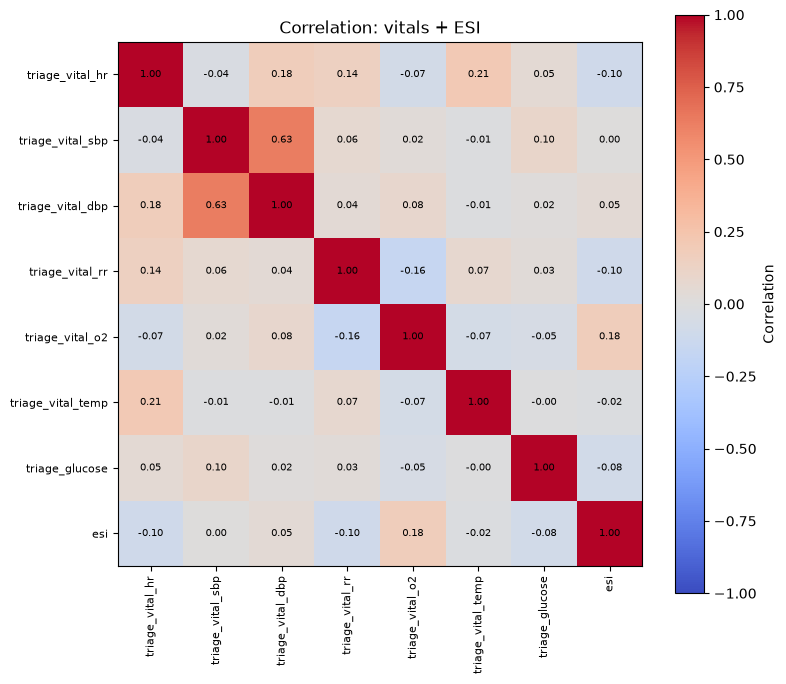

In [11]:
# Correlation Heatmap (Vitals and ESI)
cols = fam["vitals"] + [TARGET]
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))

# Paint the matrix; diverging colormap so negative/positive correlations read differently
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Label both axes with the column names
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=8)

# Write the actual correlation number inside each cell
for i in range(len(cols)):
    for j in range(len(cols)):
        value = corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7)

# Add a color scale on the side
fig.colorbar(im, ax=ax, label="Correlation")

ax.set_title("Correlation: vitals + ESI")

plt.tight_layout()
plt.savefig("figs/06_correlation.png", dpi=110)
plt.show()